In [1]:
# Base imports
import os
import pickle

# Compute imports
import numpy as np
import pandas as pd
import scipy
from tqdm.notebook import tqdm, trange

# Plotting imports
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px

# ML import
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from pyphylon.util import load_config

# Supplementary Figure 1
code can be found in 3b_ncbi_heaps_plot.ipynb

# Supplementary Figure 2

In [3]:
df_core_complete = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/CAR_genomes/df_core.csv", index_col=0)
cluster_functions = pd.read_csv('cluster_functions_annot.csv').set_index('cluster')

In [4]:
# standardizing the missing values for entire pangenome

def clean_cog(entry):
    if pd.isna(entry):
        return "missing"
    
    entry_str = str(entry).strip()
    
    if entry_str == "" or entry_str == "-":
        return "missing"
    
    return entry_str

# apply to df
cluster_functions["eggnog_COG_category"] = (
    cluster_functions["eggnog_COG_category"].apply(clean_cog)
)

In [5]:
# for entire pangenome
cog_dict = {}

for cog in cluster_functions.eggnog_COG_category.values:
    if cog != 'missing':
        for c in cog:
            if c not in cog_dict.keys():
                cog_dict[c] = 0
                cog_dict[c] += 1
            else:
                cog_dict[c] += 1
    elif cog == 'missing':
        if cog not in cog_dict.keys():
            cog_dict[cog] = 0
            cog_dict[cog] += 1
        else:
            cog_dict[cog] += 1

In [6]:
# for core genome only
core_cog_dict = {}

for cog in cluster_functions.loc[df_core_complete.index].eggnog_COG_category.values:
    if cog != 'missing':
        for c in cog:
            if c not in core_cog_dict.keys():
                core_cog_dict[c] = 0
                core_cog_dict[c] += 1
            else:
                core_cog_dict[c] += 1
    elif cog == 'missing':
        if cog not in core_cog_dict.keys():
            core_cog_dict[cog] = 0
            core_cog_dict[cog] += 1
        else:
            core_cog_dict[cog] += 1

In [7]:
cog_map = {
    # Information storage & processing
    'J': 'Translation, ribosomal structure and biogenesis',
    'A': 'RNA processing and modification',
    'K': 'Transcription',
    'L': 'Replication, recombination and repair',
    'B': 'Chromatin structure and dynamics',

    # Cellular processes & signaling
    'D': 'Cell cycle control, cell division, chromosome partitioning',
    'V': 'Defense mechanisms',
    'T': 'Signal transduction mechanisms',
    'M': 'Cell wall/membrane/envelope biogenesis',
    'N': 'Cell motility',
    'Z': 'Cytoskeleton',
    'W': 'Extracellular structures',
    'U': 'Intracellular trafficking, secretion, and vesicular transport',
    'O': 'Posttranslational modification, protein turnover, and chaperones',

    # Metabolism
    'C': 'Energy production and conversion',
    'G': 'Carbohydrate transport and metabolism',
    'E': 'Amino acid transport and metabolism',
    'F': 'Nucleotide transport and metabolism',
    'H': 'Coenzyme transport and metabolism',
    'I': 'Lipid transport and metabolism',
    'P': 'Inorganic ion transport and metabolism',
    'Q': 'Secondary metabolites biosynthesis, transport and catabolism',

    # Poorly characterized
    'S': 'Function unknown',

    'missing': 'missing'
}

In [8]:
def get_broad_category(letter):
    if letter in ['J', 'A', 'K', 'L', 'B']:
        return 'Information storage & processing'
    elif letter in ['D', 'Y', 'V', 'T', 'M', 'N', 'Z', 'W', 'U', 'O']:
        return 'Cellular processes and signaling'
    elif letter in ['C', 'G', 'E', 'F', 'H', 'I', 'P', 'Q']:
        return 'Metabolism'
    elif letter in ['R', 'S']:
        return 'Poorly characterized'
    else:
        return 'missing'

In [9]:
core_cog_plot = pd.DataFrame([
    {
        "letter": letter,
        "count": count,
        "subcategory": cog_map.get(letter, letter),
        "category": get_broad_category(letter)
    }
    for letter, count in core_cog_dict.items()
])

In [10]:
total = core_cog_plot["count"].sum()

core_cog_plot["percent"] = core_cog_plot["count"] / total * 100

In [11]:
core_cog_plot["label"] = (
    core_cog_plot["letter"] + " (" +
    core_cog_plot["percent"].round(2).astype(str) + "%)"
)

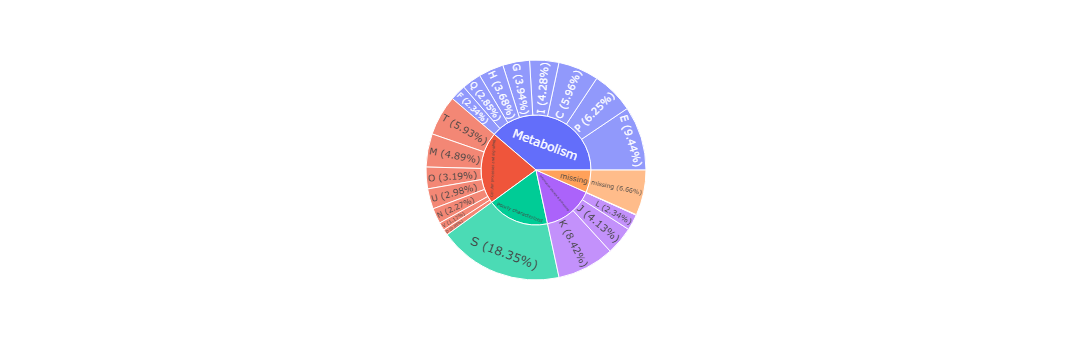

In [12]:
fig = px.sunburst(
    core_cog_plot,
    path=["category", "label"],
    values="count",
)

fig.show()

# Supplementary Figure 3

In [23]:
A_binarized = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/A_binarized.csv", index_col=0)
L_binarized = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/L_binarized.csv", index_col=0)
df_acc_complete = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/CAR_genomes/df_acc.csv", index_col=0)

In [26]:
phylon_order = ['mobile_EPS_1',
                 'mobile_EPS_2',
                 'mobile_abx_metal_resistance',
                 'mobile_pKLC102_type_1',
                 'mobile_pKLC102_type_2',
                 'mobile_phage_1',
                 'mobile_LESGI3',
                 'mobile_ST773_ST1203_aux',
                 'mobile_LHR',
                 'mobile_phage_3',
                 'mobile_phage_2',
                 'mobile_PAGI1',
                 'mobile_PAGI46',
                 'China_ST463',
                 'clone_C_associated',
                 'ST549',
                 'ST244',
                 'ST179_ST155',
                 'serotype_O3',
                 'serotype_O6_dominant',
                 'ST27',
                 'serotype_O4_dominant',
                 'ST277_dominant',
                 'ST111',
                 'serotype_O11_dominant',
                 'ST235',
                 'ST309',
                 'ST253']

In [27]:
## virulence genes
vfdb_genes = pd.read_csv('panaroo_vfdb_hits.tsv', sep = '\t', header = None)
vfdb_genes.columns =  ["qseqid","sseqid", "pident", "length", "qcovhsp", "evalue", "bitscore", "stitle"]

In [30]:
vf_genes = list(set(df_acc_complete.index).intersection(set(vfdb_genes.qseqid)))

result = pd.DataFrame(
    index=vf_genes,
    columns=A_binarized.index,
    dtype=float
)

for phylon in A_binarized.index:
    strains_with_affinity = A_binarized.loc[phylon] == 1
    n_affinity = strains_with_affinity.sum()

    if n_affinity == 0:
        result[phylon] = np.nan
        continue

    # subset strains that have affinity for phylon
    subset = df_acc_complete.loc[:, strains_with_affinity]

    # fraction of strains with gene
    frac = subset.sum(axis=1) / n_affinity

    # Check if gene belongs to phylon in L_binarized
    # Genes missing in L_binarized for this phylon are treated as 0
    genes_in_phylon = L_binarized[phylon].reindex(vf_genes).fillna(0)

    # Mask fraction: set frac to 0 where gene is not in phylon
    frac_masked = frac * genes_in_phylon

    result[phylon] = frac_masked

data = result.T.loc[phylon_order]
data_nonzero = data.loc[(data != 0).any(axis=1)]

# cog: Series of eggnog_COG_category indexed by gene
cog_first = cluster_functions.loc[data_nonzero.columns, 'eggnog_COG_category']
cog_first = cog_first.fillna('-')

# Keep only first letter and sort based on abundane of cog letter
cog_first = cog_first.astype(str).str[0]
cog_counts = cog_first.value_counts()  # default descending order
gene_cog_abundance = cog_first.map(cog_counts)
genes_sorted = cog_first.to_frame(name='COG').assign(abundance=gene_cog_abundance).sort_values(by=['abundance', 'COG'], ascending=[False, True]).index

data_sorted = data_nonzero[genes_sorted]

In [32]:
vf_plot_df = pd.DataFrame(index = data_sorted.columns.values, columns = ['function', 'COG_letter', 'vf_gene_name'])
vf_plot_df['function'] = [cluster_functions.loc[idx].loc['product'] for idx in vf_plot_df.index.values]
vf_plot_df['COG_letter'] = [cluster_functions.loc[idx].loc['eggnog_COG_category'] for idx in vf_plot_df.index.values]
vf_plot_df['COG_letter'] = vf_plot_df['COG_letter'].fillna('-')
vf_plot_df['COG_letter'] = [el[0] for el in vf_plot_df['COG_letter']]


for vf in vf_plot_df.index.values:
    ### if there is only 1 hit, add gene name from vfdb
    if type(vfdb_genes.set_index('qseqid').loc[vf]) == pd.core.series.Series:
        vf_plot_df.loc[vf, 'vf_gene_name'] = vfdb_genes.set_index('qseqid').loc[vf, 'stitle'].split(') (')[1].split(')')[0]
    else:
        ### if there is are more than one hit (max 2), add gene name from hit with lowest eval; if eval is the same, add nmae from hit with highest qcovhsp
        df = vfdb_genes.set_index('qseqid').loc[vf]
        evals = df['evalue'].values
        qcovs = df['qcovhsp'].values
        if evals[0] != evals[1]:
            vf_plot_df.loc[vf, 'vf_gene_name'] = df.iloc[np.argmin(evals)].stitle.split(') (')[1].split(')')[0]
        elif evals[0] == evals[1]:
            vf_plot_df.loc[vf, 'vf_gene_name'] = df.iloc[np.argmax(qcovs)].stitle.split(') (')[1].split(')')[0]

# grouping by COG and then sorting gene names by alphabetcal order 
grouped = vf_plot_df.groupby("COG_letter")
vf_sorted_values = []

for cog, group in grouped:
    group_sorted = group.sort_values(by="vf_gene_name")
    for idx in group_sorted.index.values:
        vf_sorted_values.append(idx)

vf_plot_df = vf_plot_df.loc[vf_sorted_values]

In [33]:
# sorting and renaming columns of data_sorted
data_sorted = data_sorted[vf_plot_df.index.values]
data_sorted.columns = vf_plot_df.vf_gene_name.values
data_sorted

,pvcD,wbpG,hisF2,hisH2,phzC1,phzE1,phzH,pvdH,pvdM,pvdM,...,vgrG2b,wbpB,wbpD,wzx,lasR,PA2364,exsE,tse4,vgrG2b,wzy
mobile_EPS_1,0.964789,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
mobile_EPS_2,0.978437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
China_ST463,0.000000,0.000000,0.000000,0.000000,0.916667,0.944444,1.000000,1.000000,0.972222,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.944444,0.000000,1.000000,1.0,0.000000,0.000000
clone_C_associated,0.000000,0.000000,0.000000,0.000000,0.964286,0.964286,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.0,0.000000,0.000000
ST549,0.000000,1.000000,1.000000,1.000000,0.982759,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.982759,1.000000,1.000000,1.0,0.000000,1.000000
ST244,0.000000,0.967391,0.967391,0.967391,0.989130,0.989130,1.000000,1.000000,0.000000,0.989130,...,1.000000,0.967391,0.967391,0.967391,0.989130,0.967391,1.000000,1.0,0.000000,0.967391
ST179_ST155,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,1.000000,0.000000
serotype_O3,0.000000,0.000000,0.000000,0.000000,0.974684,0.962025,1.000000,0.974684,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.911392,0.000000,1.000000,1.0,0.000000,0.000000
serotype_O6_dominant,0.000000,0.000000,0.000000,0.000000,0.984674,0.980843,0.996169,0.984674,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.900383,0.000000,0.996169,1.0,0.000000,0.000000
ST27,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.0,0.000000,0.000000


<Axes: >

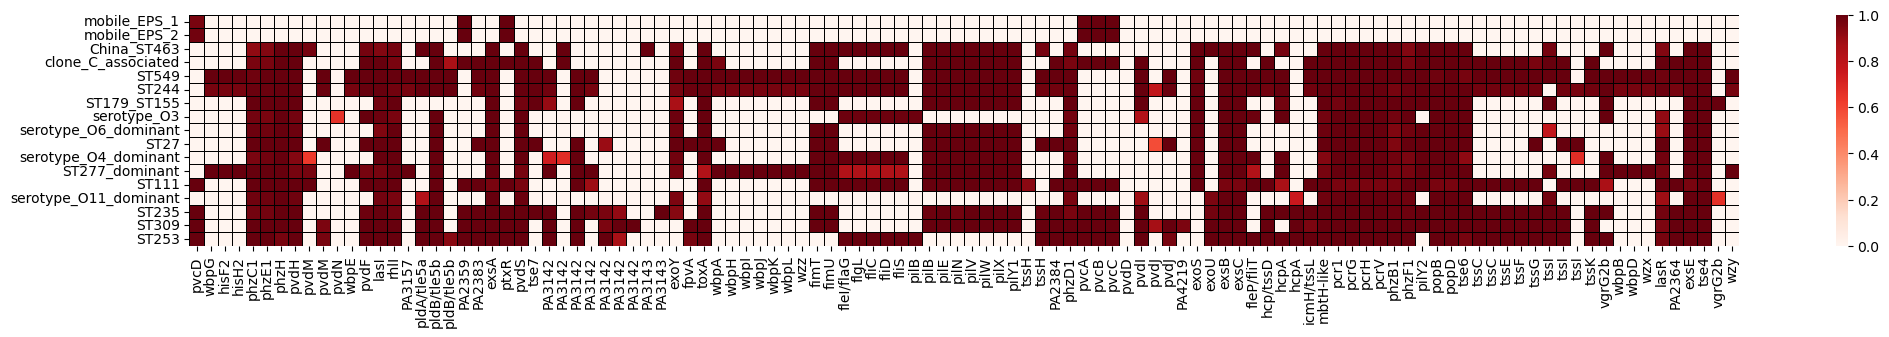

In [34]:
plt.figure(figsize=(25, 3))
sns.heatmap(data_sorted, cmap="Reds", vmin=0, vmax=1, yticklabels=True,    linewidths=0.5,linecolor='black')

# Supplementary Figure 4

In [38]:
metadata = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/interim/2d_ncbi_enriched_metadata.csv', index_col=0, dtype='object').set_index('genome_id')

In [41]:
taxonomic_phylons = ['China_ST463',
                     'clone_C_associated',
                     'ST549',
                     'ST244',
                     'ST179_ST155',
                     'serotype_O3',
                     'serotype_O6_dominant',
                     'ST27',
                     'serotype_O4_dominant',
                     'ST277_dominant',
                     'ST111',
                     'serotype_O11_dominant',
                     'ST235',
                     'ST309',
                     'ST253']

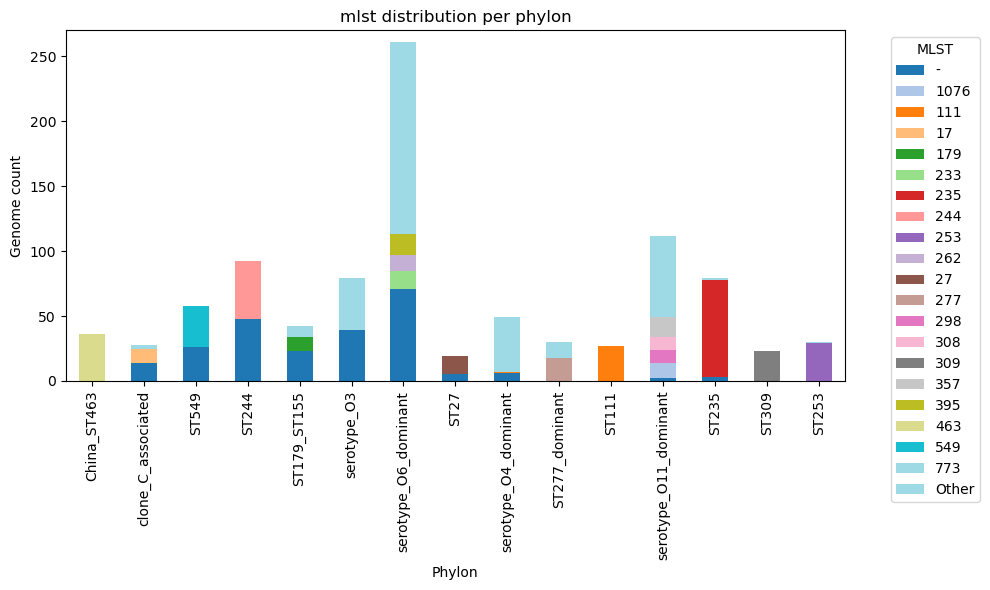

In [42]:
rows = []

for phylon in taxonomic_phylons:
    genomes = A_binarized.T.loc[A_binarized.loc[phylon] == 1].index
    
    counts = metadata.loc[genomes, 'mlst'].value_counts()
    
    for mlst, count in counts.items():
        rows.append({
            'phylon': phylon,
            'mlst': mlst,
            'count': count
        })

df_counts = pd.DataFrame(rows)

plot_df = df_counts.pivot(index='phylon', columns='mlst', values='count').fillna(0)
plot_df = plot_df.reindex(taxonomic_phylons)

mlst_totals = plot_df.sum(axis=0)
rare_mlst = mlst_totals[mlst_totals < 10].index

plot_df['Other'] = plot_df[rare_mlst].sum(axis=1)
if 'Other' in plot_df.columns and (plot_df['Other'] == 0).all():
    plot_df = plot_df.drop(columns='Other')

plot_df = plot_df.drop(columns=rare_mlst)

plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20',
    edgecolor='none',
    ylim = (0, 270)

)

plt.ylabel('Genome count')
plt.xlabel('Phylon')
plt.title('mlst distribution per phylon')
plt.legend(title='MLST', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Supplementary Figure 5

In [43]:
serotypes_df = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/serotyping_results/combined_serotypes.tsv', sep = '\t').set_index('Genome')

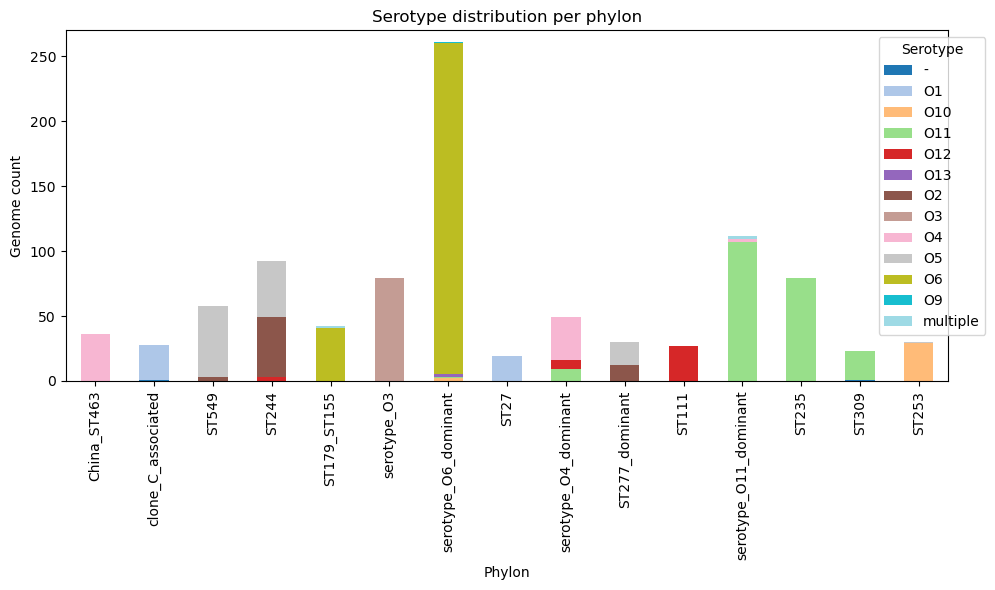

In [44]:
rows = []

for phylon in taxonomic_phylons:
    genomes = A_binarized.T.loc[A_binarized.loc[phylon] == 1].index
    
    counts = metadata.loc[genomes, 'serotype'].value_counts()
    
    for serotype, count in counts.items():
        rows.append({
            'phylon': phylon,
            'serotype': serotype,
            'count': count
        })

df_counts = pd.DataFrame(rows)

plot_df = df_counts.pivot(index='phylon', columns='serotype', values='count').fillna(0)
plot_df = plot_df.reindex(taxonomic_phylons)


plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20',
    edgecolor='none',
    ylim = (0, 270)

)

plt.ylabel('Genome count')
plt.xlabel('Phylon')
plt.title('Serotype distribution per phylon')
plt.legend(title='Serotype', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Supplementary Figure S6

In [47]:
mobile_phylons = ['mobile_EPS_1',
                 'mobile_EPS_2',
                 'mobile_abx_metal_resistance',
                 'mobile_pKLC102_type_1',
                 'mobile_pKLC102_type_2',
                 'mobile_phage_1',
                 'mobile_LESGI3',
                 'mobile_ST773_ST1203_aux',
                 'mobile_LHR',
                 'mobile_phage_3',
                 'mobile_phage_2',
                 'mobile_PAGI1',
                 'mobile_PAGI46']

<Axes: xlabel='mlst'>

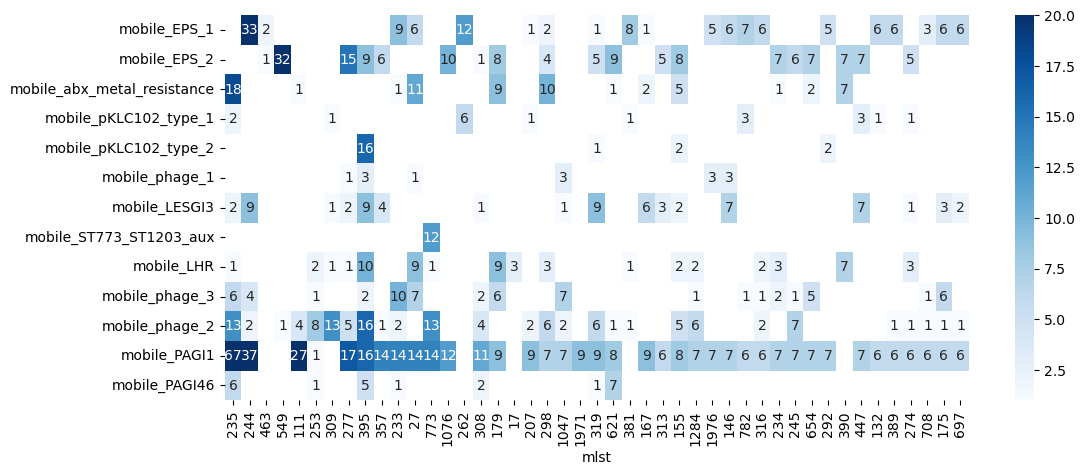

In [48]:
mlst_df = pd.DataFrame(columns = metadata.mlst.value_counts()[1:46].index, index = mobile_phylons)

for phylon in mobile_phylons:
    mlst_dist = metadata.loc[A_binarized.T[A_binarized.loc[phylon] == 1].index].mlst.value_counts()
    for st in mlst_df.columns:
        if st in mlst_dist.index.values:
            # print(mlst_dist.loc[st])
            mlst_df.loc[phylon, st] = mlst_dist.loc[st]

plt.figure(figsize=(12, 5))
sns.heatmap(mlst_df.astype(float), cmap = 'Blues', vmax = 20, annot = True)

# Supplementary Figure S7

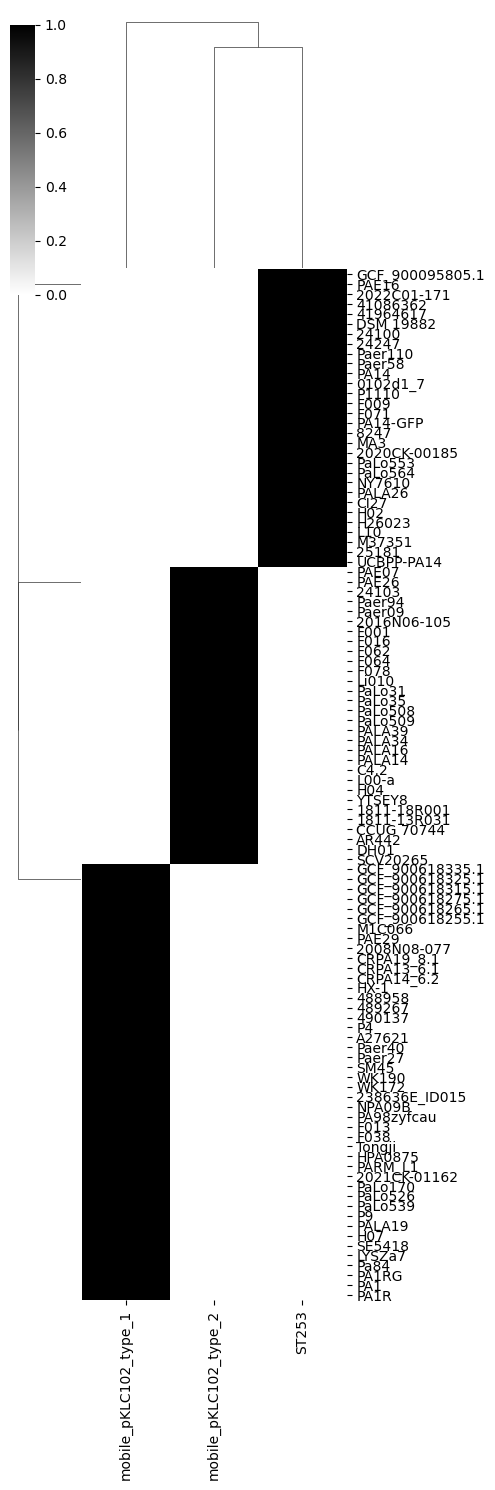

In [45]:
pKLC_df = A_binarized.loc[['mobile_pKLC102_type_1','mobile_pKLC102_type_2', 'ST253']].loc[:, (A_binarized.loc[['mobile_pKLC102_type_1','mobile_pKLC102_type_2', 'ST253']] != 0).any(axis=0)]

new_cols = []

for idx in metadata.loc[pKLC_df.columns].index:
    if type(metadata.loc[idx, 'strain']) == str:
        new_cols.append(metadata.loc[idx, 'strain'])
    else:
        new_cols.append(idx)

pKLC_df.columns = new_cols  

sns.clustermap(pKLC_df.T,
              cmap = 'binary',
              yticklabels = True,
              figsize=(5, 15))

# Supplementary Figure S8
created using optNMF.py 